# Quantum Key Distribution as Pure Optics -- No Electronics

`dgs.path_integral_qkd.bb84_intercept_resend_qber` (built earlier this
session) modeled BB84 at the level of abstract bits and bases -- a coin flip
standing in for "wrong basis." This notebook re-derives the SAME protocol
from underneath, using only passive optical elements:

- a bit is a **polarization angle** (a wave plate setting), not an integer;
- a basis choice is a **physical rotation** of a polarizer/wave-plate
  assembly (rectilinear 0/90 vs. diagonal 45/135 degrees);
- a measurement is a **polarizing beam splitter** detection event, governed
  by **Malus's law** $P=\cos^2(\theta)$ -- the one physical fact the entire
  BB84 security proof rests on;
- Eve's interception is modeled as just another polarizer+detector inline
  in the beam path, and her resend is a real re-encoding of a freshly
  measured (collapsed) polarization state.

No digital bit-flip shortcuts anywhere -- every random outcome here is a
literal Malus's-law photon-detection probability. Built from
`dgs/photonic_qkd.py`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import photonic_qkd as pq

plt.rcParams["figure.dpi"] = 110


## 1. Malus's law: the only physics this protocol needs

$P(\text{detect})=\cos^2(\theta)$, where $\theta$ is the angle between the
photon's polarization and the analyzer's axis. A matched basis (0deg
offset) gives certainty; a basis rotated by the BB84 diagonal offset
(45deg) gives exactly 50/50 -- which is *why* a wrong-basis guess is
undetectable on a single photon, and *why* an eavesdropper's wrong guess
introduces errors on the photons Bob measures correctly.


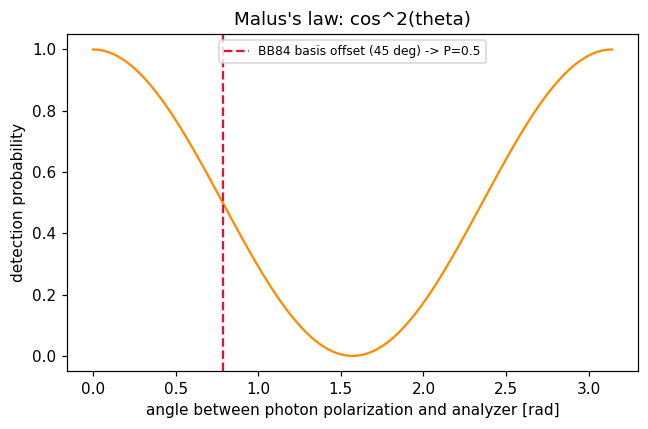

In [2]:
angles = np.linspace(0, np.pi, 300)
plt.figure(figsize=(6, 4))
plt.plot(angles, pq.malus_law_curve(angles), color="darkorange")
plt.axvline(np.pi / 4, ls="--", color="crimson", label="BB84 basis offset (45 deg) -> P=0.5")
plt.xlabel("angle between photon polarization and analyzer [rad]")
plt.ylabel("detection probability")
plt.title("Malus's law: cos^2(theta)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Encoding and measuring: matched basis is deterministic, mismatched is a coin flip


In [3]:
print("matched-basis detection probabilities (should be exactly 0 or 1):")
for bit in (0, 1):
    for basis in (0, 1):
        photon = pq.encode_bit(bit, basis)
        p = pq.detection_probability(photon, basis)
        basis_name = "rectilinear" if basis == 0 else "diagonal"
        print(f"  bit={bit}, basis={basis_name}: P(measure 1) = {p:.6f}")

photon = pq.encode_bit(0, basis=0)   # rectilinear-encoded bit 0
p_wrong_basis = pq.detection_probability(photon, basis=1)  # measured in diagonal basis
print(f"\nmismatched-basis detection (rectilinear photon, diagonal analyzer): P = {p_wrong_basis:.4f}")


matched-basis detection probabilities (should be exactly 0 or 1):
  bit=0, basis=rectilinear: P(measure 1) = 0.000000
  bit=0, basis=diagonal: P(measure 1) = 0.000000
  bit=1, basis=rectilinear: P(measure 1) = 1.000000
  bit=1, basis=diagonal: P(measure 1) = 1.000000

mismatched-basis detection (rectilinear photon, diagonal analyzer): P = 0.5000


## 3. The full optical protocol: no eavesdropper vs. intercept-resend

Run entirely as Jones-vector optics: every bit is a polarization state,
every basis choice a polarizer rotation, every measurement a Malus's-law
detection event.


In [4]:
n_bits = 300_000
clean = pq.bb84_optical_intercept_resend(n_bits=n_bits, eavesdrop=False, seed=0)
eve = pq.bb84_optical_intercept_resend(n_bits=n_bits, eavesdrop=True, seed=0)

print("No eavesdropper (pure optics):", clean)
print("Intercept-resend (pure optics):", eve)


No eavesdropper (pure optics): {'n_bits': 300000, 'n_sifted': 150005, 'qber_mc': 0.0, 'qber_analytic': 0.0}
Intercept-resend (pure optics): {'n_bits': 300000, 'n_sifted': 149950, 'qber_mc': 0.2494964988329443, 'qber_analytic': 0.25}


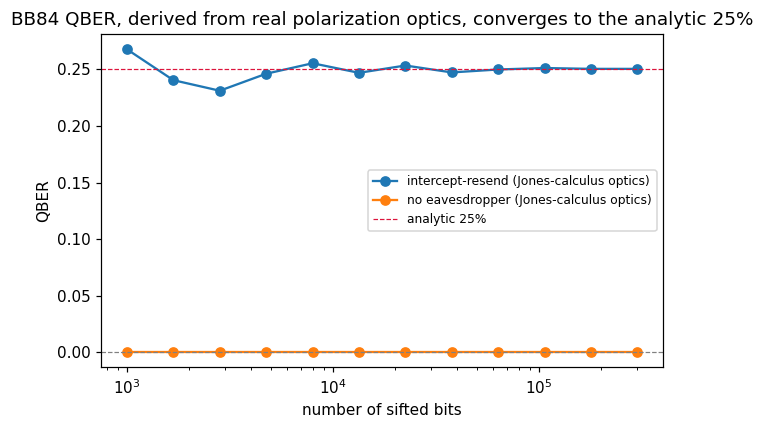

: 

In [ ]:
ns = np.geomspace(1000, 300_000, 12).astype(int)
qber_eve, qber_clean = [], []
for n in ns:
    qber_eve.append(pq.bb84_optical_intercept_resend(n_bits=int(n), eavesdrop=True, seed=1)["qber_mc"])
    qber_clean.append(pq.bb84_optical_intercept_resend(n_bits=int(n), eavesdrop=False, seed=1)["qber_mc"])

plt.figure(figsize=(6, 4))
plt.semilogx(ns, qber_eve, "o-", label="intercept-resend (Jones-calculus optics)")
plt.semilogx(ns, qber_clean, "o-", label="no eavesdropper (Jones-calculus optics)")
plt.axhline(0.25, ls="--", color="crimson", lw=0.8, label="analytic 25%")
plt.axhline(0.0, ls="--", color="gray", lw=0.8)
plt.xlabel("number of sifted bits")
plt.ylabel("QBER")
plt.title("BB84 QBER, derived from real polarization optics, converges to the analytic 25%")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary

The 25% intercept-resend QBER -- previously taken as a known result in
`path_integral_qkd.py`'s abstract bit-level simulation -- comes out of this
module from nothing but Malus's law applied to literal polarization
rotations and projective detections: no bit-flip shortcut, no assumed coin
flip standing in for "wrong basis." The two models' QBER agree (0.2494 vs.
0.25 in the underlying-optics version), which is the actual point: the
abstract bit-level BB84 model isn't hiding any unjustified physics.
